In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_csv("/content/Sales.csv")

In [6]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [8]:
df.columns


Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [9]:
df.shape

(200, 4)

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


In [11]:
# Checking Null values
df.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [12]:
df.dtypes
#Data.isnull().sum()#
# # T is for Transpose

,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


In [13]:
# Step 2 - EDA

# EDA - Exploratory Data Analysis | Data Audit

# After importing : Immediate step is to get the friendship with the data.

# Regular available function

# Data.shape        # R : dim()
# Data.columns    # R : names()
#Data.head(2)    # R : head()
# Data.tail(2)    # R : tail()
#Data.info()   # R : str()
df.describe().T # R : summary()
# Data.isnull()

,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


In [15]:
# Creating Data audit Report
# Use a general function that returns multiple values

def var_summary(x):
    return pd.Series([x.count(), x.isnull().sum(), x.sum(), x.mean(), x.median(),  x.std(), x.var(), x.min(), x.quantile(0.01), x.quantile(0.05),x.quantile(0.10),x.quantile(0.25),x.quantile(0.50),x.quantile(0.75), x.quantile(0.90),x.quantile(0.95), x.quantile(0.99),x.max()],
                  index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'MIN', 'P1' , 'P5' ,'P10' ,'P25/Q1' ,'P50/Q2' ,'P75/Q3' ,'P90' ,'P95' ,'P99' ,'MAX'])

In [16]:
def var_summary(x):
    uc = x.mean()+(2*x.std())
    lc = x.mean()-(2*x.std())

    for i in x:
        if i<lc or i>uc:
            count = 1
        else:
            count = 0
    outlier_flag = count
    return pd.Series([x.count(), x.isnull().sum(), x.sum(), x.mean(), x.median(),  x.std(), x.var(), x.min(), x.quantile(0.01), x.quantile(0.05),x.quantile(0.10),x.quantile(0.25),x.quantile(0.50),x.quantile(0.75), x.quantile(0.90),x.quantile(0.95), x.quantile(0.99),x.max() , lc , uc,outlier_flag],
                  index=['N', 'NMISS', 'SUM', 'MEAN','MEDIAN', 'STD', 'VAR', 'MIN', 'P1' , 'P5' ,'P10' ,'P25' ,'P50' ,'P75' ,'P90' ,'P95' ,'P99' ,'MAX','LC','UC','outlier_flag'])



# UC = MEAN + 2 STD

In [17]:
df.apply(lambda x: var_summary(x)).T

,N,NMISS,SUM,MEAN,MEDIAN,STD,VAR,MIN,P1,P5,...,P25,P50,P75,P90,P95,P99,MAX,LC,UC,outlier_flag
TV,200.0,0.0,29408.5,147.0425,149.75,85.854236,7370.949893,0.7,5.387,13.195,...,74.375,149.75,218.825,261.44,280.735,292.907,296.4,-24.665973,318.750973,0.0
Radio,200.0,0.0,4652.8,23.2640,22.90,14.846809,220.427743,0.0,0.399,1.995,...,9.975,22.90,36.525,43.52,46.810,49.400,49.6,-6.429618,52.957618,0.0
Newspaper,200.0,0.0,6110.8,30.5540,25.75,21.778621,474.308326,0.3,0.999,3.600,...,12.750,25.75,45.100,59.07,71.825,89.515,114.0,-13.003242,74.111242,0.0
Sales,200.0,0.0,3026.1,15.1305,16.00,5.283892,27.919517,1.6,4.784,6.600,...,11.000,16.00,19.050,21.71,23.800,25.507,27.0,4.562715,25.698285,0.0


In [18]:
#var_summary(advt.TV)
var_summary(df.Newspaper)

,0
N,200.000000
NMISS,0.000000
SUM,6110.800000
MEAN,30.554000
MEDIAN,25.750000
STD,21.778621
VAR,474.308326
MIN,0.300000
P1,0.999000
P5,3.600000


In [19]:
df["Newspaper"] = df.Newspaper.clip(lower = 10  , upper = 100)

In [20]:
var_summary(df.Newspaper)

,0
N,200.000000
NMISS,0.000000
SUM,6267.100000
MEAN,31.335500
MEDIAN,25.750000
STD,20.537900
VAR,421.805316
MIN,10.000000
P1,10.000000
P5,10.000000


In [21]:
# Handling Outliers | I am capping that with Var > P99 then Var = P99 [Upper CAP]
#                                         Var < P01 then Var = P01 [Lower CAP]

df['Sales'] = df['Sales'].clip(lower = 10, upper = 100)

In [22]:
var_summary(df.Sales)

,0
N,200.000000
NMISS,0.000000
SUM,3119.200000
MEAN,15.596000
MEDIAN,16.000000
STD,4.583725
VAR,21.010537
MIN,10.000000
P1,10.000000
P5,10.000000


In [23]:
# Handling Missings
# Fill with mean

df['Sales']=df['Sales'].fillna(df['Sales'].mean())

In [24]:

# Now you have to take care of REgression related Rules and assumption

In [25]:
# Distribution of variables
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

<ipython-input-26-0347397e822c>:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Sales)


<Axes: xlabel='Sales', ylabel='Density'>

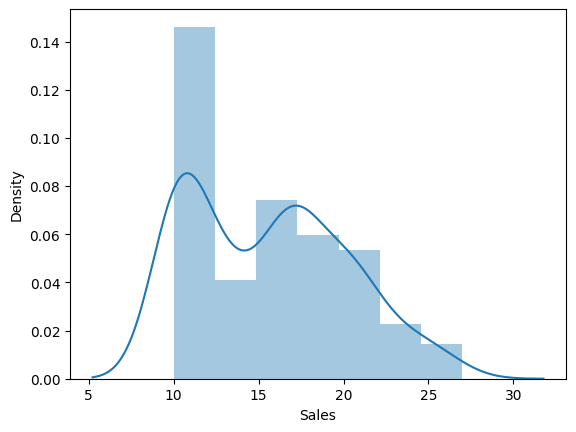

In [26]:
# To check the normality if Y[Sales]
#________________________________________________________________
# Choice 1- You could got the job being done with  - SEABORN PACKAGE
sns.distplot(df.Sales)

# Choice 2 - I could have got the same job being done with - PANDAS itself
#Data.Sales.hist() # uvivariate

<Axes: >

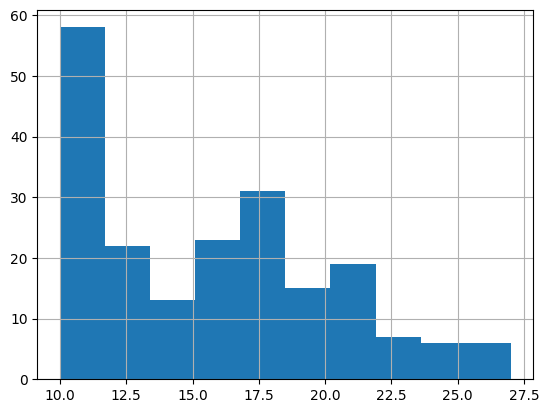

In [ ]:
df.Sales.hist()

<ipython-input-27-bb93d0824a31>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( df.Newspaper )


<Axes: xlabel='Newspaper', ylabel='Density'>

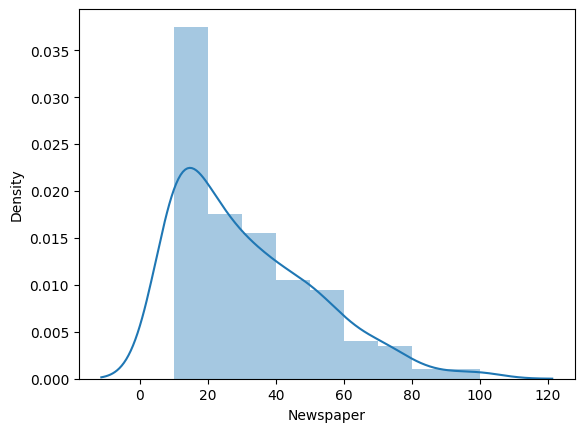

In [27]:
sns.distplot( df.Newspaper )

<Axes: >

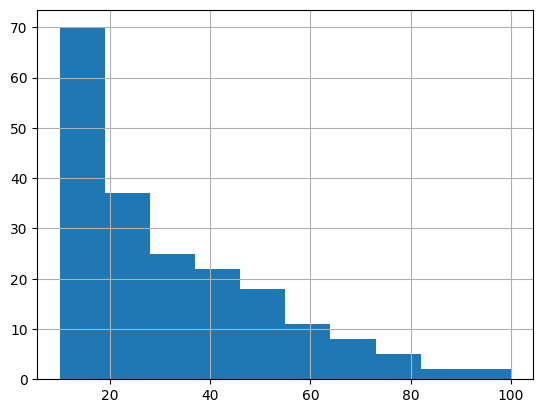

In [28]:
df.Newspaper.hist()

<ipython-input-29-32337a0a348d>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df.Radio)


<Axes: xlabel='Radio', ylabel='Density'>

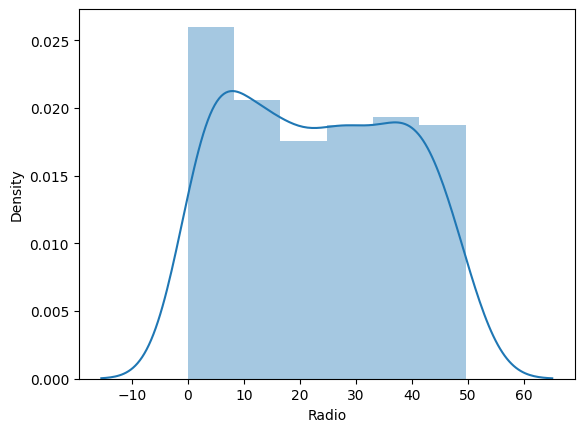

In [29]:
sns.distplot(df.Radio)

<ipython-input-30-eae4af154cff>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot( df.TV)


<Axes: xlabel='TV', ylabel='Density'>

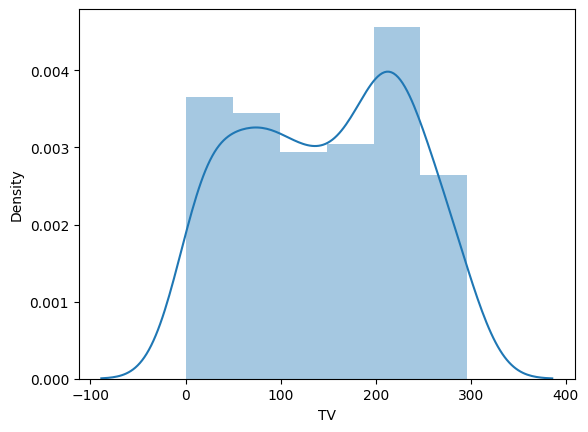

In [30]:
sns.distplot( df.TV)

In [31]:
#Sales seems to be normal distribution. Spending on newspaper advertisement seems to be righ skewed.
#Most of the spends on newspaper is fairly low where are spend on radio and tv seems be uniform distribution.
#Spends on tv are comparatively higher then spens on radio and newspaper.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 4.0 MB/s eta 0:00:00
  Attempting uninstall: seaborn
    Found existing installation: seaborn 0.13.1
    Uninstalling seaborn-0.13.1:
      Successfully uninstalled seaborn-0.13.1


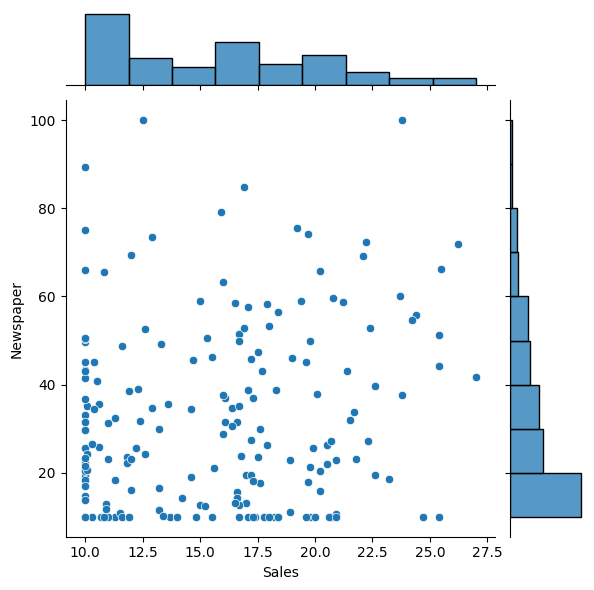

In [32]:
!pip install seaborn --upgrade # make sure you have the latest version of seaborn

import seaborn as sns

# Assumption No. 3  - Is there a relationship between sales and spend various advertising channels?

# Sales Vs. Newspaper advertisement spends
# Both Bi-variate(Scatter) + Univariate(Histogram)

sns.jointplot(x='Sales', y='Newspaper', data=df) # Pass data as a DataFrame and specify 'x' and 'y'

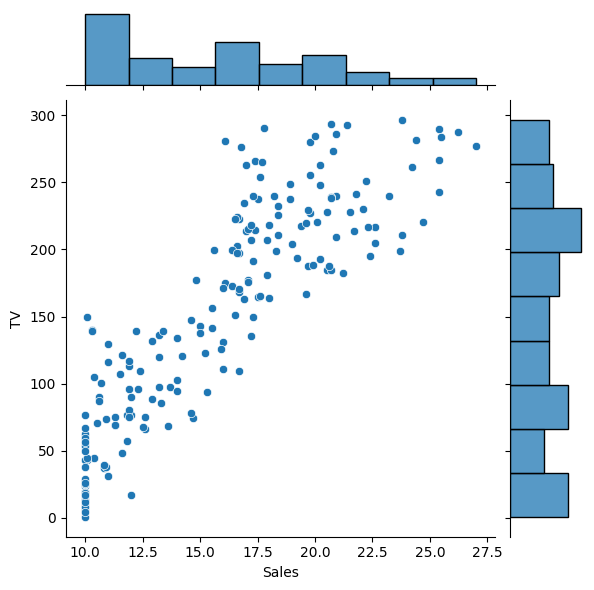

In [34]:
#Sales Vs. TV advertisement spends

sns.jointplot(x='Sales', y='TV', data=df) # Pass 'x' and 'y' as keyword arguments

In [ ]:
#Sales and spend on newpaper is not highly correlaed where are sales and spend on tv is highly correlated.

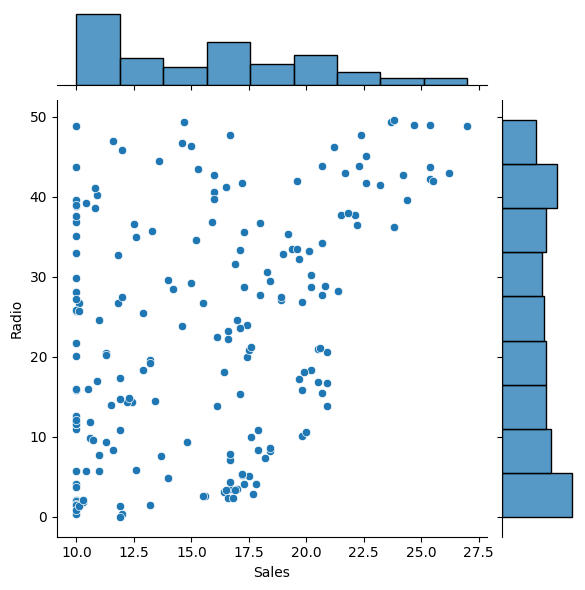

In [35]:
#Sales Vs. Radio advertisement spends

sns.jointplot(x= 'Sales',y='Radio',data=df)

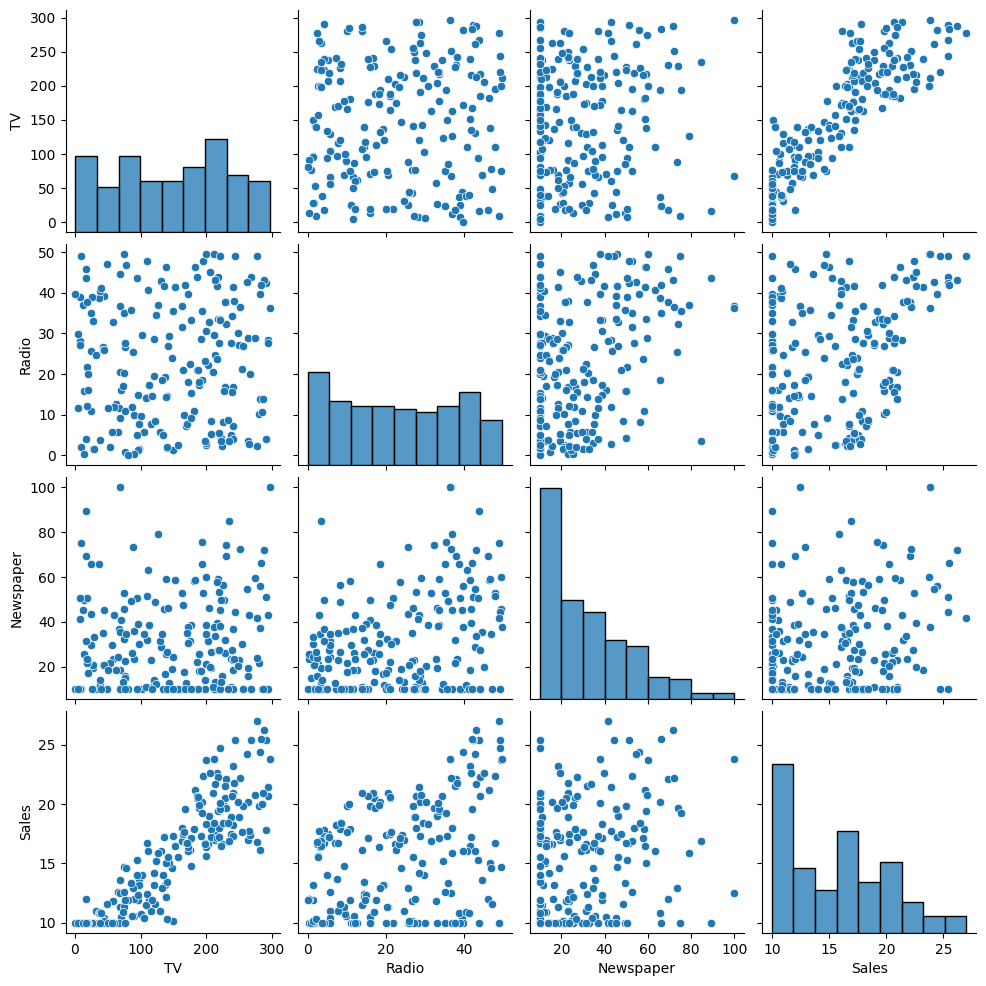

In [37]:
# Visualizing pairwise correleation )

sns.pairplot (df)

In [38]:
# Calculating correlations

df.TV.corr( df.Sales)

0.883655853451101

In [39]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.065510,0.883656
Radio,0.054809,1.000000,0.368934,0.378195
Newspaper,0.065510,0.368934,1.000000,0.174389
Sales,0.883656,0.378195,0.174389,1.000000


<Axes: >

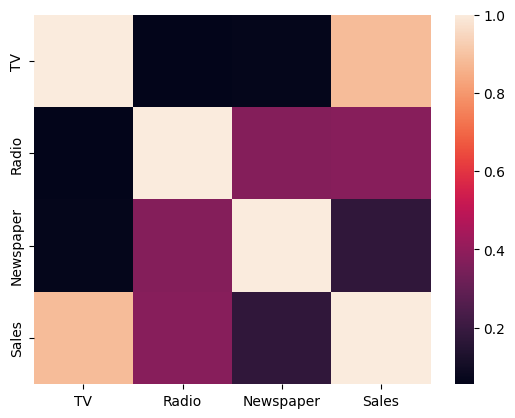

In [40]:
# Visualizing the correlations
#The darker is the color, the stronger is the correlation

sns.heatmap( df.corr())

In [ ]:
#The diagonal of the above matirx shows the auto-correlation of the variables.
 #It is always 1. You can observe that the correlation betweeb TV and Sales is highest i.e. 0.88 and then betweeb sales and radio correlations can vary from -1 to +1. Closer to +1 means strong positive correlation and close -1 means strong negative correlation.
 #Closer to 0 means not very strongly correlated.

In [ ]:
#Building Regression Model
#Linear regression is an approach for modeling the relationship between a scalar dependent variable y and one or more explanatory variables (or independent variables) denoted X. The case of one explanatory variable is called simple linear regression. For more than one explanatory variable, the process is called multiple linear regression
#A simple linear regression model is given by Y=mX+b
#where m is the slope and b is the y-intercept. Y is the dependent variable and X is the explanatory variable.
#Very briefly and simplistically, Linear Regression is a class of techniques for fitting a straight line to a set of data points

In [41]:
import statsmodels.formula.api as smf

import pandas as pd

#Python module - classes and functions for the estimation - statistical models, - smf

In [43]:
lm = smf.ols('Sales ~ TV + Radio + Newspaper', df).fit() # Ordinary Least Square method : For Regression MOdel
# method for estimating the unknown parameters in a linear regression model.

In [44]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.888
Method:                 Least Squares   F-statistic:                     528.3
Date:                Thu, 01 Aug 2024   Prob (F-statistic):           1.27e-93
Time:                        14:37:02   Log-Likelihood:                -367.12
No. Observations:                 200   AIC:                             742.2
Df Residuals:                     196   BIC:                             755.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.4457      0.287     22.444      0.000       5.879       7.012
TV             0.0462      0.001     36.437      0.000       0.044       0.049
Radio          0.1027      0.008     13.039      0.000       0.087       0.118
Newspaper     -0.0011      0.006     -0.197      0.844      -0.012       0.010
==============================================================================
Omnibus:                        1.550   Durbin-Watson:                   2.113
Prob(Omnibus):                  0.461   Jarque-Bera (JB):                1.592
Skew:                           0.158   Prob(JB):                        0.451
Kurtosis:                       2.698   Cond. No.                         461.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [46]:

lm = smf.ols('Sales ~ TV + Radio',df).fit() # rerunning the model again, removing the news paper from the list

In [47]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.889
Method:                 Least Squares   F-statistic:                     796.3
Date:                Thu, 01 Aug 2024   Prob (F-statistic):           4.06e-95
Time:                        14:38:06   Log-Likelihood:                -367.14
No. Observations:                 200   AIC:                             740.3
Df Residuals:                     197   BIC:                             750.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      6.4255      0.268     24.001      0.000       5.898       6.953
TV             0.0462      0.001     36.560      0.000       0.044       0.049
Radio          0.1021      0.007     13.971      0.000       0.088       0.117
==============================================================================
Omnibus:                        1.557   Durbin-Watson:                   2.108
Prob(Omnibus):                  0.459   Jarque-Bera (JB):                1.606
Skew:                           0.162   Prob(JB):                        0.448
Kurtosis:                       2.704   Cond. No.                         425.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [48]:
# Getting model parameters
lm.params

,0
Intercept,6.425513
TV,0.046210
Radio,0.102116


In [49]:
# Parameters at 95% confidence intervals

lm.conf_int()

,0,1
Intercept,5.897552,6.953475
TV,0.043718,0.048703
Radio,0.087702,0.116530
